## 회귀 분석으로 보는 벅슨의 역설

심슨의 역설과 마찬가지로 벅슨의 역설을 보통 회귀 분석으로 설명하지 않는다. 그런데 이 문제 역시 회귀 분석으로 보면 보다 명확하다. 벅슨의 역설을 예시하는 데이터는 많지 않다. 그 이유는 벅슨의 역설은 인과 추론에서 말하는 충돌 요인(collider)의 맥락에서 주로 발생하는데, 많은 경우 변인의 통제 여부 보다는 (인지하지 못하는) 표본의 제한성에서 오는 경우가 많다. 아쉽지만 벅슨의 역설을 일으키는 상황을 상정하고 이에 맞춰 가상의 데이터를 생성한 후 이를 회귀 분석을 통해 다시 음미해보는 순서로 내용을 살펴보도록 하자. 

## 플롯

여기 적는 내용은 스토리텔링이지만 또 단순한 스토리텔링은 아니다. 코로나19와 흡연의 관계를 조사하기로 한 연구자가 있다고 하자. 그는 입원 병원의 자료를 살펴보고 놀라운 결론을 얻었다. 흡연하는 사람일수록 코로나 증세가 덜 심하다는 관계를 파악했다. 인과 관계인지 상관 관계인지는 더 조사가 필요하겠지만, 일반적인 통념과 반대되는 결론을 얻게 된 것이다. 이러한 추론을 맞는 것일까? 먼저 아래의 인과 다이어그램을 보자. 

:::{ .column-margin }
[이 연구](https://www.nature.com/articles/s41467-020-19478-2)는 코로나19 인식에 있어서 충돌 요인의 문제를 다양하게 지적하고 있다. 
:::

![입원 여부는 충돌 요인(collider)이 된다.](https://miro.medium.com/max/1400/1*_YSCycwMY90nltgg-qMEWw.png){ .figure7 }

담배를 많이 피울수록 혹은 그래왔을수록 코로나19 이외의 요인으로도 병원이 입원할 가능성이 높아진다. 또한 코로나 증세가 심할수록 병원에 입원할 가능성이 높아진다. 이 경우 병원에 입원한다는 것은 두 요인(흡연의 정도, 코로나19 중증도)에 영향을 받는 충돌 요인이 된다. 따라서 이를 통제할 경우 흡연의 정도와 코로나19의 중증도 사이의 관계가 왜곡된다. 이러한 취지로 데이터를 생성해보도록 하자. 

In [90]:
# Basic packages
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Stats models 
import statsmodels.formula.api as sm
import statsmodels.stats.sandwich_covariance as sw
import statsmodels as statsmodels

In [437]:
def generate_unit_df(pack_of_cigar, n, sd=1, covid_threshold=2, cigar_threshold=6):

    mean_of_severity_covid = pack_of_cigar * 0.2
    mean_of_severity_cigar = pack_of_cigar * 0.9

    df = pd.DataFrame(
        {   
            'pack_of_cigar': pack_of_cigar,
            'covid_severity': np.random.normal(mean_of_severity_covid, 1, n),
            'cigar_severity': np.random.normal(mean_of_severity_cigar, 0.5, n)
        }
    )
    df = df.assign(
        **{
            'covid_severity': np.where(df['covid_severity'] > 0, df['covid_severity'], 0), 
            'cigar_severity': np.where(df['cigar_severity'] > 0, df['cigar_severity'], 0), 
            'is_hospitalized': np.where((df['covid_severity'] > covid_threshold) | (df['cigar_severity'] > cigar_threshold), "Yes", "No"),
            'is_observed': np.random.uniform(0, 1, n)
        }
    )

    df = df.query(
            "(`covid_severity` <= 3)"
        )
    df = df.query(
            "(`is_hospitalized` == 'Yes') | (`is_hospitalized` == 'No' & `is_observed` <= 0.2)"  
    )

    return df 
    
res = pd.DataFrame()

for pack in range(0, 10):
    res = pd.concat([res, generate_unit_df(pack, 100)])

위의 플롯에 따라서 가상의 데이터를 생성했다. 코로나19 중증도는 흡연의 정도에 양의 영향을 받는다. 그리고 흡연의 정도는 별도로 건강에 악영향을 준다. 따라서 코로나19 중증도, 흡연의 정도 모두 해당 환자가 입원할 가능성을 결정하게 된다. 

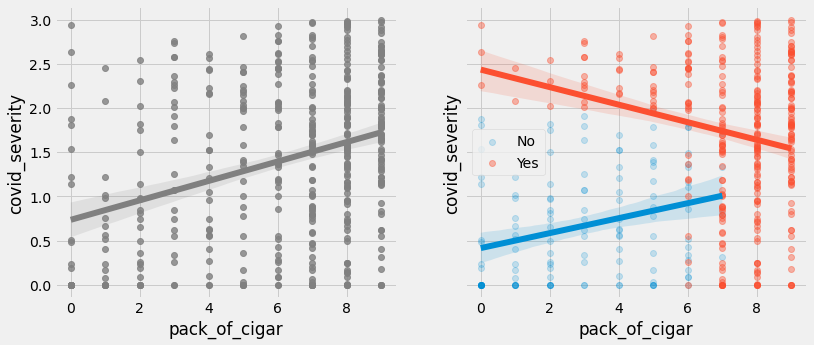

In [447]:
#| fig-cap: "충돌 요인은 어떻게 작용하는가?"

palette = sns.color_palette("dark")
#sns.palplot(palette)

plt.rcParams['figure.figsize'] = [12, 5]
plt.style.use("fivethirtyeight")# for pretty graphs
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
sns.regplot(x = 'pack_of_cigar',y = 'covid_severity', data = res, ax=ax1, color='grey')
#
for i, value in enumerate(res['is_hospitalized'].unique()):
    ax2 = sns.regplot(x="pack_of_cigar", y="covid_severity",
                     #color=colors[value],
                     #marker=markers[i],      
                     scatter_kws={'alpha': 0.4 if value == "Yes" else 0.2},        
                     data=res[res['is_hospitalized'] == value],
                     label=value, 
                     ax = ax2)

ax2.legend(loc='best');

위의 왼쪽 그래프에서 보듯이 잘 추출된 표본 전체에 대해서는 흡연의 정도와 코로나19의 중증도 사이에 양의 관계가 잘 보인다. 그런데, 만일 충돌 요인인 입원 여부를 고려하면 어떨까? 오른쪽 그림에서 보듯이 병원에 입원한 환자에 대해서는 음의 상관성이 관찰된다. 왜 이럴까? 병원의 입원하는 요인에는 코로나19의 중증도 이외에도 흡연 여부가 있다. 흡연을 많이 할수록 코로나와 관계 없이 그 자체로 입원할 가능성이 높아지고 코로나19 중증도에 대해서 이들의 경우 다양한 상태를 지니게 된다. 

In [436]:
ols1 = sm.ols(formula="covid_severity ~ pack_of_cigar", data=res).fit(use_t=True)
ols2 = sm.ols(formula="covid_severity ~ pack_of_cigar + is_hospitalized", data=res).fit(use_t=True)
ols3 = sm.ols(formula="covid_severity ~ pack_of_cigar + is_hospitalized", data=res[res.is_hospitalized=="Yes"]).fit(use_t=True)
#ols1.summary()
#ols2.summary()

from stargazer.stargazer import Stargazer
stargazer = Stargazer([ols1, ols2, ols3])
stargazer

회귀 분석에서 이러한 결과를 그대로 확인할 수 있다. 위 분석에서 현실에 가장 근접한 분석은 (1)이다. 만일 입원 여부를 통제하게 될 경우(식 (2))는 흡연의 정도가 코로나19의 중증도에 미치는 영향을 왜곡하게 된다. 벅슨의 역설의 극단적인 버전은 입원한 환자만 표본으로 삼아 분석을 실시하는 경우이다. 이 경우 (3)에서 보듯이 흡연의 정도와 코로나19 중증도의 정도가 가장 많이 왜곡된다. 